# Generative Models

<figure>
    <img src="https://drive.google.com/uc?export=view&id=1UjunyOkHxHewQ51X75Edq8VYlQshNyRr" alt="Picture" style="display: block; margin: 0 auto;" />
    <figcaption style="text-align: center;"><strong>Fig. 1: Face Generation using GAN. Source: <a href="https://www.eff.org/files/2018/02/20/malicious_ai_report_final.pdf">https://www.eff.org/files/2018/02/20/malicious_ai_report_final.pdf</a></strong></figcaption>
</figure>



## Imports of the project

In [1]:
# CELL 1: imports_and_global_dependencies
# Description: Imports all libraries required for VAE, GAN, and Diffusion experiments.

import os
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

import tensorflow as tf  # kept because it already appears in the base notebook

from sklearn.manifold import TSNE
from scipy.stats import norm

## Auxiliary functions

In [2]:
# CELL 2: auxiliary_functions
# Description: Helper functions for reshaping tensors, generating noise, visualizing samples, and plotting losses.

class Reshape(nn.Module):
    def __init__(self, *args):
        super(Reshape, self).__init__()
        self.shape = args

    def forward(self, x):
        return x.view(x.size(0), *self.shape)


def generate_noise(batch_size, noise_dim):
    return torch.randn(batch_size, noise_dim, 1, 1).to(device)


def generate_images(generator, title="Generated Images", noise_dim=100, tanh_output=True):
    noise = generate_noise(25, noise_dim)

    generator.eval()
    with torch.no_grad():
        generated_images = generator(noise)

    if tanh_output:
        generated_images = (generated_images + 1.0) / 2.0  # map [-1, 1] -> [0, 1]

    generated_images = generated_images.view(25, 28, 28).detach().cpu().numpy()

    fig, axes = plt.subplots(5, 5, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(generated_images[i], cmap='gray')
        ax.axis('off')

    plt.suptitle(title)
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()


def plot_images(rows, cols, images, title):
    """Displays images in a grid."""
    images = images.reshape(rows, cols, 28, 28)
    grid = np.zeros(shape=(rows * 28, cols * 28))

    for i in range(rows):
        for j in range(cols):
            grid[i * 28:(i + 1) * 28, j * 28:(j + 1) * 28] = images[i, j]

    plt.figure(figsize=(10, 10))
    plt.imshow(grid, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()


def plot_loss_curves(losses_g, losses_d, title="GAN Loss Curves"):
    plt.figure(figsize=(8, 5))
    plt.plot(losses_g, label="Generator Loss")
    plt.plot(losses_d, label="Discriminator Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

We load the MNIST dataset

In [3]:
# CELL 3: mnist_dataset_for_vae_and_gan
# Description: Loads the MNIST dataset for the VAE and GAN sections.

transform = transforms.Compose([
    transforms.ToTensor(),
])

trainset = datasets.MNIST(root='MNIST_data/', train=True, download=True, transform=transform)
testset = datasets.MNIST(root='MNIST_data/', train=False, download=True, transform=transform)

# Optional subset for faster testing
# trainset = Subset(trainset, range(0, len(trainset)//10))
# testset = Subset(testset, range(0, len(testset)//10))

trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
testloader = DataLoader(testset, batch_size=32, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.95MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.09MB/s]


Using device: cuda


# Variational Auto-Encoders

> #### **Exercise:** Using the MNIST dataset train a variational autoencoder. To do this you must implement the encoder, the decoder, the reparametrize trick, and the loss function. Then, show the generated latent space. Finally, analyze the obtained results.

### Encoder

|Layer (Type)| Output Shape |
|-|-|
| Input Layer | (28, 28, 1) |
| Conv2D | (28, 28, 32) |
| Conv2D | (14, 14, 32) |
| Conv2D | (14, 14, 64) |
| Flatten | 14x14x64 |
| Dense $(z \ \mu)$  | Latent Dim |
| Dense $(z \ log \ var)$ | Latent Dim |
| Sampling($z$) | Latent Dim |

Activation Functions: ReLU


In [4]:
# CELL 4: vae_encoder
# Description: Implements the VAE encoder, including the reparameterization trick.

class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.latent_dim = 5

        # Convolutional Layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)   # (1, 28, 28) -> (32, 28, 28)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=2, padding=1)  # (32, 28, 28) -> (32, 14, 14)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)  # (32, 14, 14) -> (64, 14, 14)

        self.fc1 = nn.Linear(14 * 14 * 64, self.latent_dim)  # mu
        self.fc2 = nn.Linear(14 * 14 * 64, self.latent_dim)  # log_var

        self.Flatten = nn.Flatten()

        self.encoder = nn.Sequential(
            self.conv1,
            nn.ReLU(),
            self.conv2,
            nn.ReLU(),
            self.conv3,
            nn.ReLU()
        )

    # Reparametrization Trick (Sampling)
    def sampling(self, mu, log_var):
        std = torch.exp(0.5 * log_var)

        # eps -> mean = 0 and std = 1.0
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x = self.encoder(x)
        x = self.Flatten(x)
        mu = self.fc1(x)
        log_var = self.fc2(x)
        z = self.sampling(mu, log_var)
        return z, mu, log_var

### Decoder

| Layer (Type)                | Output Shape |
|-----------------------------|--------------|
| Dense        | (Latent Dim, 14x14x64)    |
| Reshape                     | (64, 14, 14)   |
| ConvTranspose2D | (32, 28, 28) |
| ConvTranspose2D | (28, 28, 1) |
| ConvTranspose2D | (28, 28, 1)  |

Activation Functions:
- ReLU and Sigmoid for the output layer

In [5]:
# CELL 5: vae_decoder
# Description: Implements the VAE decoder to reconstruct MNIST images from the latent space.

class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.latent_dim = 5

        # Fully Connected Layer
        self.fc = nn.Linear(self.latent_dim, 14 * 14 * 64)

        # Convolutional Transpose Layers
        self.conv2d_transpose1 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)  # -> (32, 28, 28)
        self.conv2d_transpose2 = nn.ConvTranspose2d(32, 16, kernel_size=3, stride=1, padding=1)                    # -> (16, 28, 28)
        self.conv2d_transpose3 = nn.ConvTranspose2d(16, 1, kernel_size=3, stride=1, padding=1)                     # -> (1, 28, 28)

        self.decoder = nn.Sequential(
            self.fc,
            Reshape(64, 14, 14),
            self.conv2d_transpose1,
            nn.ReLU(),
            self.conv2d_transpose2,
            nn.ReLU(),
            self.conv2d_transpose3,
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(x)

### VAE Model

In [6]:
# CELL 6: vae_model_training
# Description: Defines the VAE model, loss function, optimizer, and training loop.

class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        z, mu, log_var = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, mu, log_var

    def loss(self, x, x_hat, mu, log_var):
        KL = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
        recostruction = F.mse_loss(x_hat, x, reduction='sum')
        return KL + recostruction


In [ ]:
# CELL 6.1: vae_model_training

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


def train(model, trainloader, optimizer, epochs=5):
    model.train()
    history = []

    for epoch in range(epochs):
        epoch_loss = 0.0

        for i, (x, _) in enumerate(trainloader):
            x = x.to(device)

            x_hat, mu, log_var = model(x)
            loss = model.loss(x, x_hat, mu, log_var)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            if i % 100 == 0:
                print(f'\rEpoch {epoch + 1}/{epochs}, Iteration {i}, Loss: {loss.item():.4f}', end="")

        avg_epoch_loss = epoch_loss / len(trainloader.dataset)
        history.append(avg_epoch_loss)
        print(f"\nEpoch {epoch + 1} average loss: {avg_epoch_loss:.4f}")

    return history


vae_history = train(model, trainloader, optimizer, epochs=5)

Epoch 1/5, Iteration 1800, Loss: 1483.9414
Epoch 1 average loss: 56.8633
Epoch 2/5, Iteration 1800, Loss: 1320.1384
Epoch 2 average loss: 42.1817
Epoch 3/5, Iteration 1800, Loss: 1236.5538
Epoch 3 average loss: 39.4648
Epoch 4/5, Iteration 1300, Loss: 1249.0586

### Latent Space

In [9]:
# CELL 7: vae_latent_space_visualization
# Description: Projects the latent space to 2D using t-SNE.

import numpy as np
from sklearn.manifold import TSNE
from sklearn.manifold import MDS

model.eval()
z = []
labels = []

with torch.no_grad():
    for x, y in testloader:
        x = x.to(device)
        z_, _, _ = model.encoder(x)
        z.append(z_.cpu().numpy())
        labels.append(y.numpy())

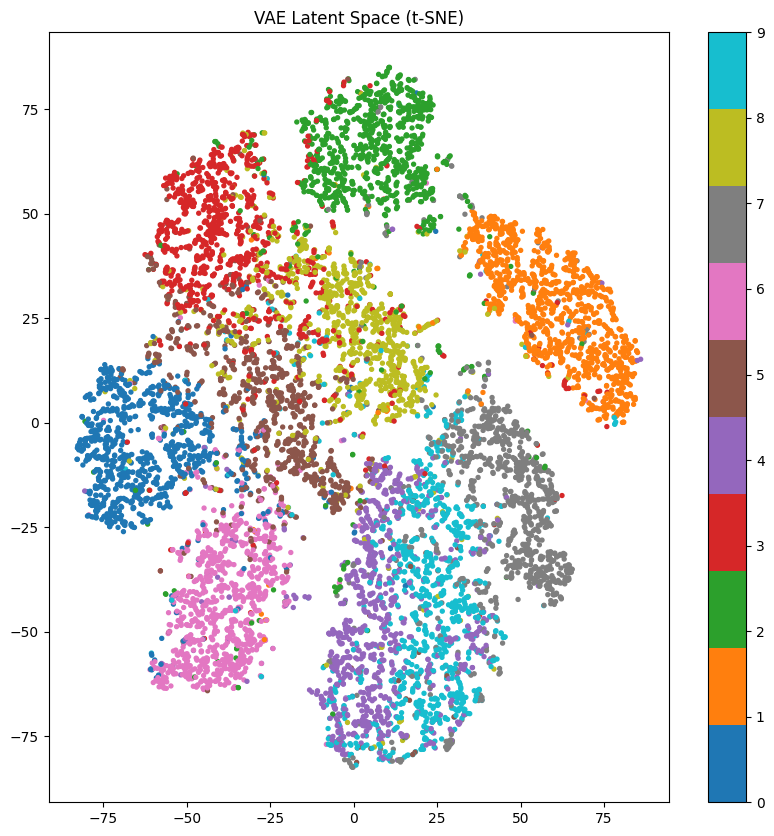

In [10]:
# MDS
z = np.concatenate(z, axis=0)
labels = np.concatenate(labels, axis=0)

tsne = TSNE(n_components=2, random_state=42)
z_2d = tsne.fit_transform(z)

plt.figure(figsize=(10, 10))
plt.scatter(z_2d[:, 0], z_2d[:, 1], c=labels, cmap='tab10', s=8)
plt.colorbar()
plt.title("VAE Latent Space (t-SNE)")
plt.show()

### Latent Space (Numbers)

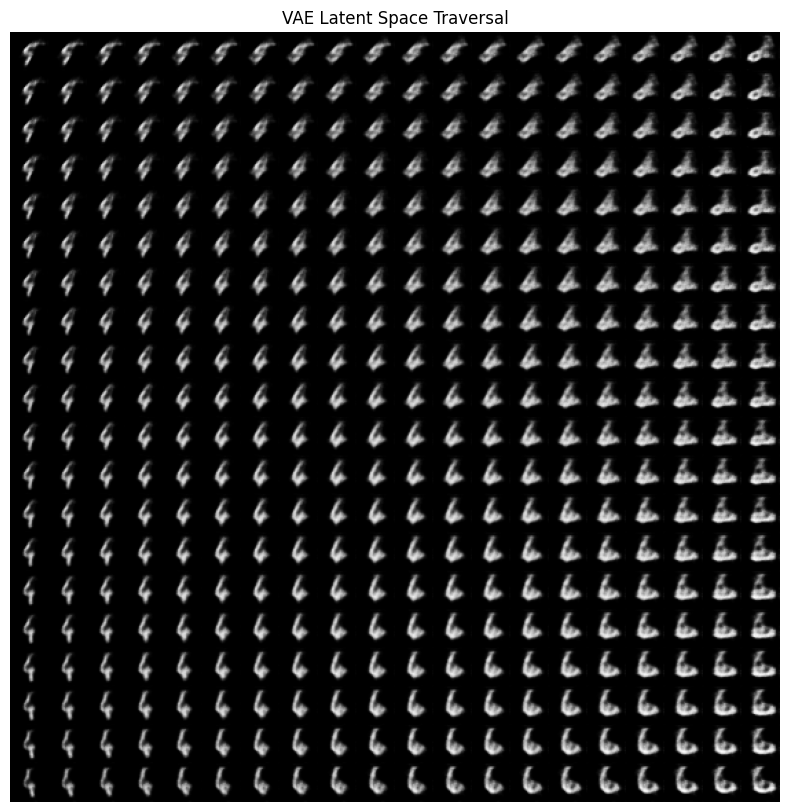

In [11]:
# CELL 8: vae_latent_space_digit_grid
# Description: Generates a digit manifold by traversing two latent dimensions.

from scipy.stats import norm
n = 20  # figure with 20x20 digits
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))

# Construct grid of latent variable values
grid_x = norm.ppf(np.linspace(0.05, 0.95, n))
grid_y = norm.ppf(np.linspace(0.05, 0.95, n))

model.eval()
with torch.no_grad():
    for i, yi in enumerate(grid_x):
        for j, xi in enumerate(grid_y):
            # With 5 latent variables, we only visualize 2 dimensions.
            # The other dimensions are fixed to 1.
            z_sample = np.array([[xi, yi, 1, 1, 1]], dtype=np.float32)
            z_sample = np.tile(z_sample, (32, 1))
            z_sample = torch.tensor(z_sample, dtype=torch.float32).to(device)

            x_decoded = model.decoder(z_sample)
            x_decoded = x_decoded.cpu().numpy()

            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[
                i * digit_size: (i + 1) * digit_size,
                j * digit_size: (j + 1) * digit_size
            ] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='gray')
plt.title("VAE Latent Space Traversal")
plt.axis('off')
plt.show()

### Reconstructions

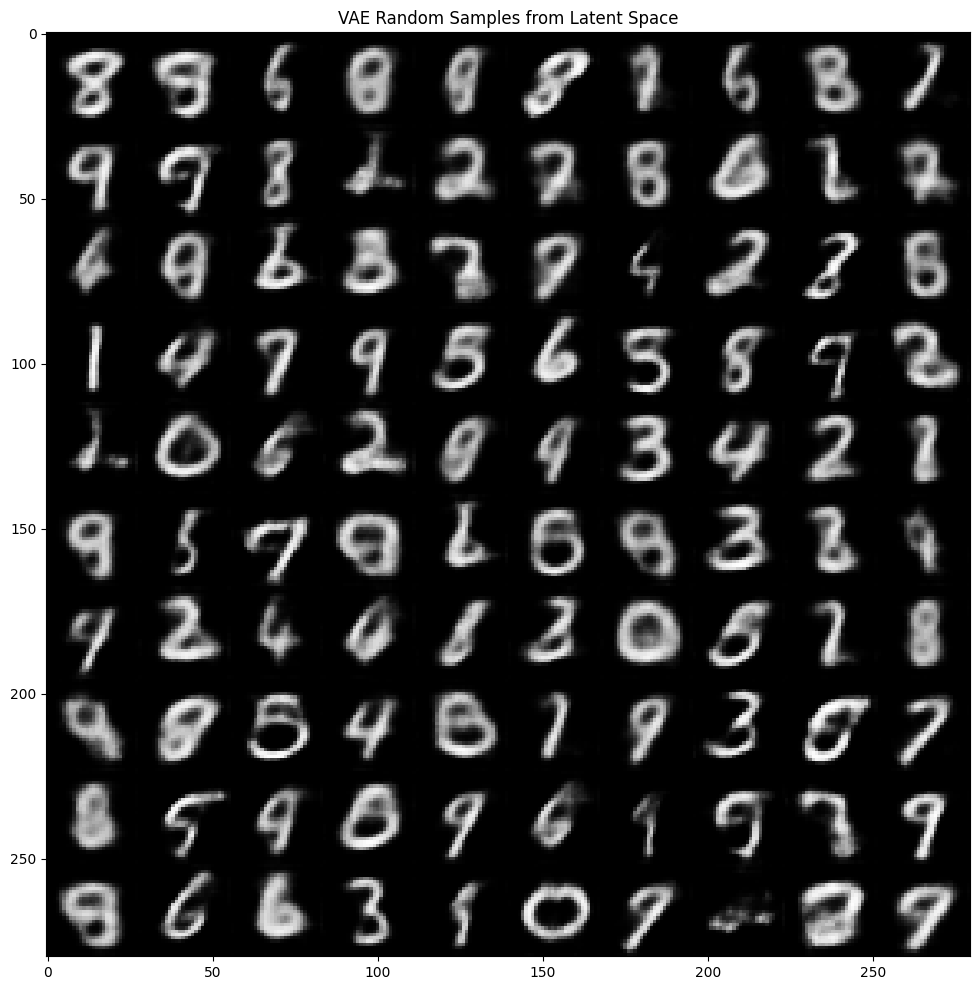

In [12]:
# CELL 9: vae_random_sampling
# Description: Samples random images from the VAE latent space.

# Grid with numbers sampled from the latent space
import numpy as np
def plot_images(rows, cols, images, title):
    '''Displays images in a grid.'''
    images = images.reshape(rows, cols, 28, 28)  # Reshape images array
    grid = np.zeros(shape=(rows*28, cols*28))
    for i in range(rows):
        for j in range(cols):
            grid[i*28:(i+1)*28, j*28:(j+1)*28] = images[i, j]


    plt.figure(figsize=(12,12))
    plt.imshow(grid, cmap='gray')
    plt.title(title)
    plt.show()


model.eval()
n = 10

with torch.no_grad():
    latent_space = torch.randn(n * n, model.encoder.latent_dim).to(device)
    images = model.decoder(latent_space).view(-1, 1, 28, 28).cpu().numpy()

plot_images(n, n, images, 'VAE Random Samples from Latent Space')

> ### **Exercise:**  Adapt the loss function to use the hyperparameter $\beta$. Then, check how the modification of this parameter influences the generation of the latent space.

https://openreview.net/pdf?id=Sy2fzU9gl

beta=0.5 | epoch 1/3 | avg loss=48.8286
beta=0.5 | epoch 2/3 | avg loss=33.1746
beta=0.5 | epoch 3/3 | avg loss=30.9396
beta=1.0 | epoch 1/3 | avg loss=49.6735
beta=1.0 | epoch 2/3 | avg loss=36.7727
beta=1.0 | epoch 3/3 | avg loss=34.8892
beta=4.0 | epoch 1/3 | avg loss=59.7271
beta=4.0 | epoch 2/3 | avg loss=49.6665
beta=4.0 | epoch 3/3 | avg loss=48.5851


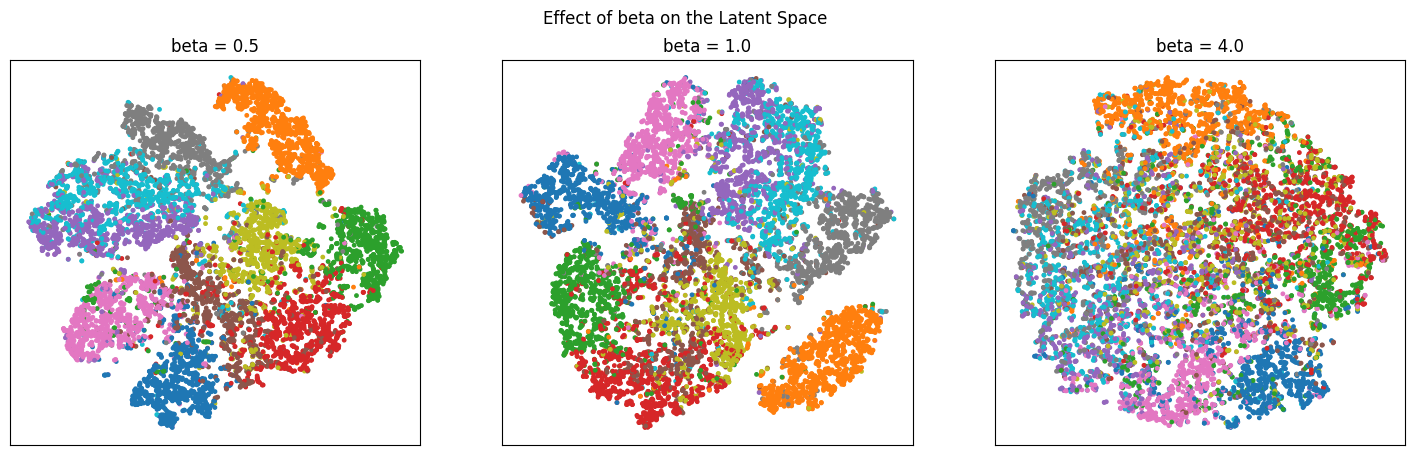

In [13]:
# CELL 10: beta_vae_experiment
# Description: Adapts the VAE loss using a beta hyperparameter and compares several beta values.

class BetaVAE(nn.Module):
    def __init__(self, beta=1.0):
        super(BetaVAE, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()
        self.beta = beta

    def forward(self, x):
        z, mu, log_var = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, mu, log_var

    def loss(self, x, x_hat, mu, log_var):
        KL = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
        recostruction = F.mse_loss(x_hat, x, reduction='sum')
        return recostruction + self.beta * KL


def train_beta_vae(beta, epochs=3):
    beta_model = BetaVAE(beta=beta).to(device)
    beta_optimizer = torch.optim.Adam(beta_model.parameters(), lr=1e-4)

    beta_model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for x, _ in trainloader:
            x = x.to(device)

            x_hat, mu, log_var = beta_model(x)
            loss = beta_model.loss(x, x_hat, mu, log_var)

            beta_optimizer.zero_grad()
            loss.backward()
            beta_optimizer.step()

            running_loss += loss.item()

        print(f"beta={beta} | epoch {epoch + 1}/{epochs} | avg loss={running_loss / len(trainloader.dataset):.4f}")

    return beta_model


BETAS = [0.5, 1.0, 4.0]
beta_models = {}

for beta in BETAS:
    beta_models[beta] = train_beta_vae(beta=beta, epochs=3)


plt.figure(figsize=(18, 5))

for idx, beta in enumerate(BETAS, start=1):
    beta_model = beta_models[beta]
    beta_model.eval()

    z = []
    labels = []

    with torch.no_grad():
        for x, y in testloader:
            x = x.to(device)
            z_, _, _ = beta_model.encoder(x)
            z.append(z_.cpu().numpy())
            labels.append(y.numpy())

    z = np.concatenate(z, axis=0)
    labels = np.concatenate(labels, axis=0)

    tsne = TSNE(n_components=2, random_state=42)
    z_2d = tsne.fit_transform(z)

    plt.subplot(1, 3, idx)
    plt.scatter(z_2d[:, 0], z_2d[:, 1], c=labels, cmap='tab10', s=6)
    plt.title(f"beta = {beta}")
    plt.xticks([])
    plt.yticks([])

plt.suptitle("Effect of beta on the Latent Space")
plt.show()

# Generative Adversarial Networks

> ### **Exercise:** Implement the Generator and the Discriminator. Then generate some samples and plot the loss of the generator and discriminator.

### Generator

---
   |Layer (type)     |          Output Shape |
   |--|--|
   |ConvTranspose2d      |     [128, 7, 7]    |
   |ConvTranspose2d      |     [128, 7, 7]    |
   |           ReLU      |         |
   |ConvTranspose2d      |     [64, 14, 14]    |
   |ConvTranspose2d      |     [64, 14, 14]    |
   |           ReLU      |         |
   |ConvTranspose2d      |     [1, 28, 28]    |
   |ConvTranspose2d      |     [1, 28, 28]    |
   |           Tanh      |         |
   
   ---


In [14]:
# CELL 11: gan_generator
# Description: Implements the baseline GAN generator.

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.conv2d_transpose1 = nn.ConvTranspose2d(100, 128, kernel_size=7, stride=1, padding=0)
        self.conv2d_transpose2 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
        self.conv2d_transpose3 = nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1)

        self.generator = nn.Sequential(
            self.conv2d_transpose1,
            nn.ReLU(),
            self.conv2d_transpose2,
            nn.ReLU(),
            self.conv2d_transpose3,
            nn.Tanh()
        )

    def forward(self, x):
        return self.generator(x)

### Discriminator

---
| Layer (type)      |         Output Shape  |
|--|--|
|      Conv2d        |   [64, 14, 14]   |
|      Conv2d        |   [64, 14, 14]   |
|   ReLU        |      |
|      Conv2d        |   [128, 7, 7]   |
|      Conv2d        |   [128, 7, 7]   |
|   ReLU        |      |
|      Conv2d        |   [1, 1, 1]   |
|     Sigmoid        |      |
---

In [15]:
# CELL 12: gan_discriminator
# Description: Implements the baseline GAN discriminator.

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.conv2d1 = nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1)
        self.conv2d2 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)
        self.conv2d3 = nn.Conv2d(128, 1, kernel_size=7, stride=1, padding=0)

        self.discriminator = nn.Sequential(
            self.conv2d1,
            nn.ReLU(),
            self.conv2d2,
            nn.ReLU(),
            self.conv2d3,
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.discriminator(x)

### Training

In [16]:
# CELL 13: gan_training
# Description: Trains the baseline GAN and stores losses.

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

generator = Generator().to(device)
discriminator = Discriminator().to(device)

generator_optimizer = torch.optim.Adam(generator.parameters(), lr=0.00005)
discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.00005)

loss_generator_iters = []
loss_discriminator_iters = []

def train():
    # Real and Fake labels
    real_label, fake_label = 1, 0

    # Loss function
    criterion = nn.BCELoss()

    for epoch in range(5):
        epoch_g_loss = 0.0
        epoch_d_loss = 0.0

        for i, (real_images, _) in enumerate(trainloader):
            batch_size = real_images.size(0)

            # Normalize real images from [0,1] to [-1,1] because generator uses Tanh
            real_images = (real_images * 2.0) - 1.0
            real_images = real_images.to(device)

            real_labels = torch.full((batch_size, 1, 1, 1), real_label, dtype=torch.float, device=device)
            fake_labels = torch.full((batch_size, 1, 1, 1), fake_label, dtype=torch.float, device=device)

            # -------------------------
            # Train the discriminator
            # -------------------------
            discriminator.zero_grad()

            output_real = discriminator(real_images)
            loss_real = criterion(output_real, real_labels)

            noise = generate_noise(batch_size, 100)
            fake_images = generator(noise)
            output_fake = discriminator(fake_images.detach())
            loss_fake = criterion(output_fake, fake_labels)

            loss_discriminator = loss_real + loss_fake
            loss_discriminator.backward()
            discriminator_optimizer.step()

            # -------------------------
            # Train the generator
            # -------------------------
            generator.zero_grad()

            output_fake_for_g = discriminator(fake_images)
            loss_generator = criterion(output_fake_for_g, real_labels)
            loss_generator.backward()
            generator_optimizer.step()

            epoch_g_loss += loss_generator.item()
            epoch_d_loss += loss_discriminator.item()

            print(
                f'\rEpoch [{epoch + 1}/5], Step [{i + 1}/{len(trainloader)}], '
                f'Loss D: {loss_discriminator.item():.4f}, Loss G: {loss_generator.item():.4f}',
                end=''
            )

        # Save images for plot on each epoch
        generate_images(generator, title=f"Baseline GAN Samples - Epoch {epoch + 1}")

        # Save epoch losses
        loss_generator_iters.append(epoch_g_loss / len(trainloader))
        loss_discriminator_iters.append(epoch_d_loss / len(trainloader))
        print()

Epoch [1/5], Step [1875/1875], Loss D: 0.0410, Loss G: 4.4057

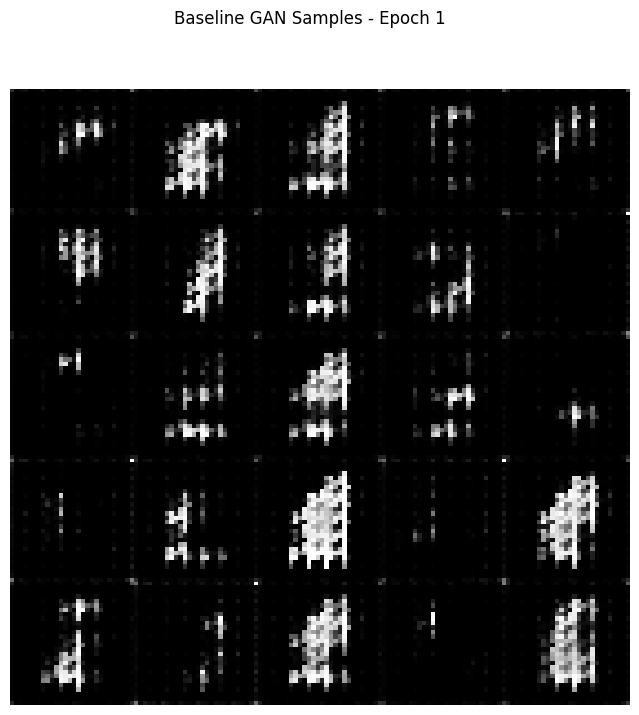


Epoch [2/5], Step [1875/1875], Loss D: 0.2522, Loss G: 2.8033

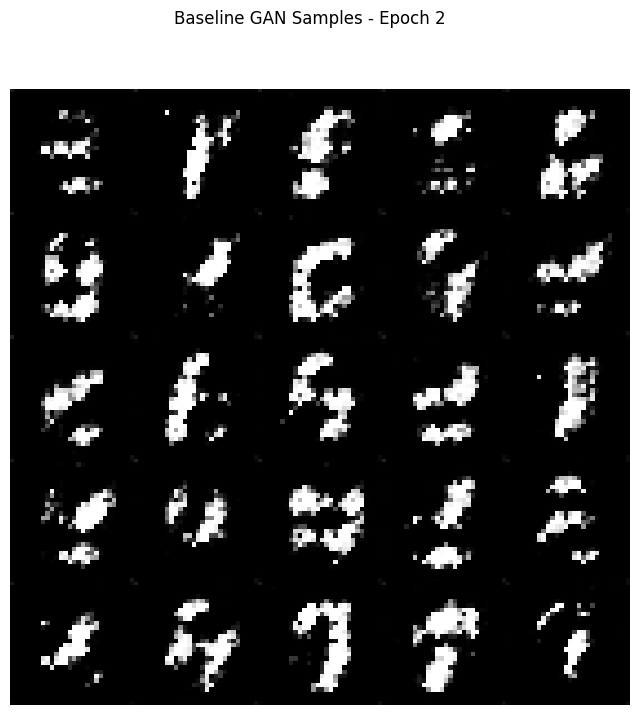


Epoch [3/5], Step [1875/1875], Loss D: 0.5138, Loss G: 2.2288

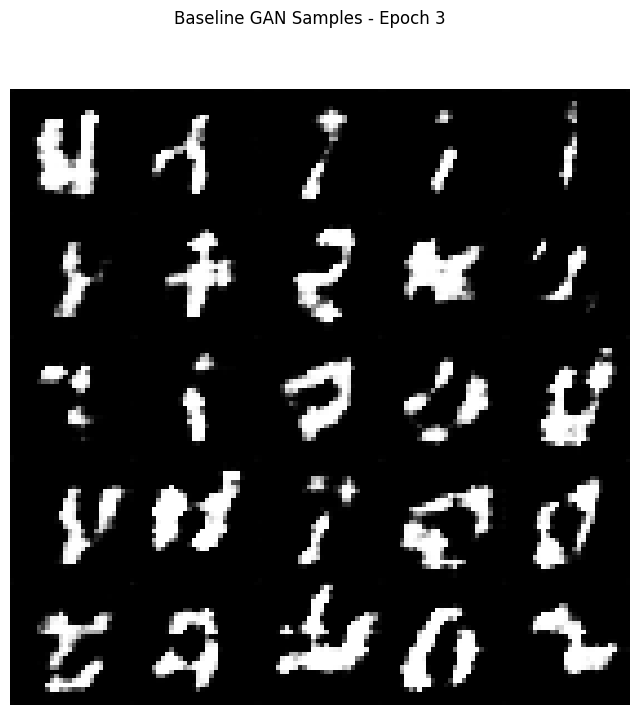


Epoch [4/5], Step [1875/1875], Loss D: 0.5206, Loss G: 1.8923

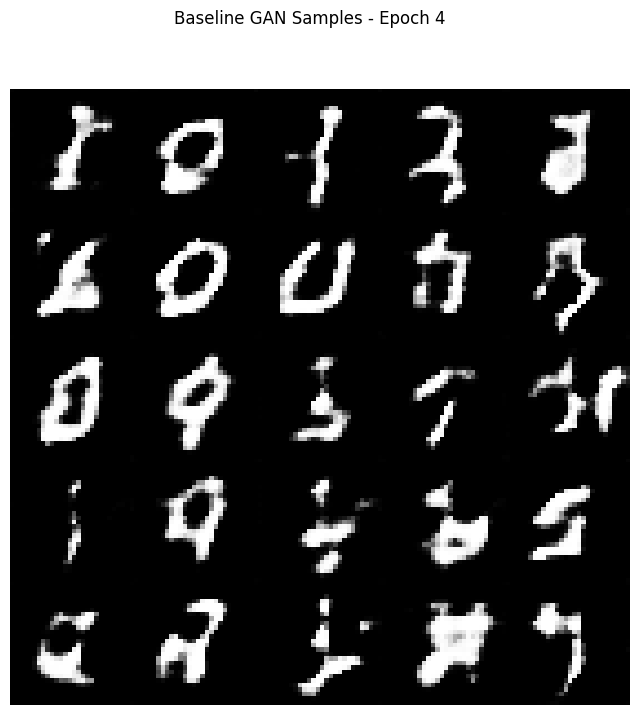


Epoch [5/5], Step [1875/1875], Loss D: 0.6337, Loss G: 1.3382

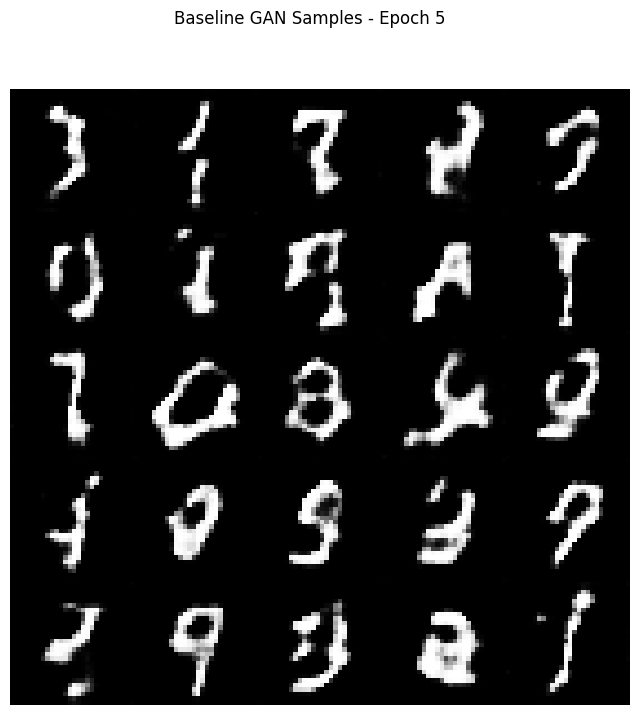

In [17]:
%matplotlib inline
train()

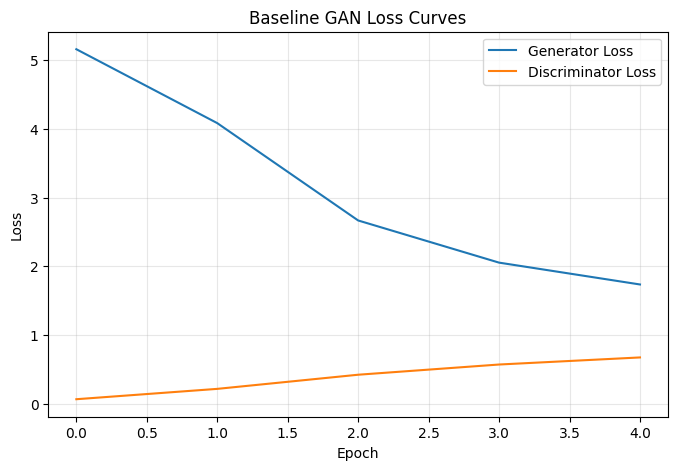

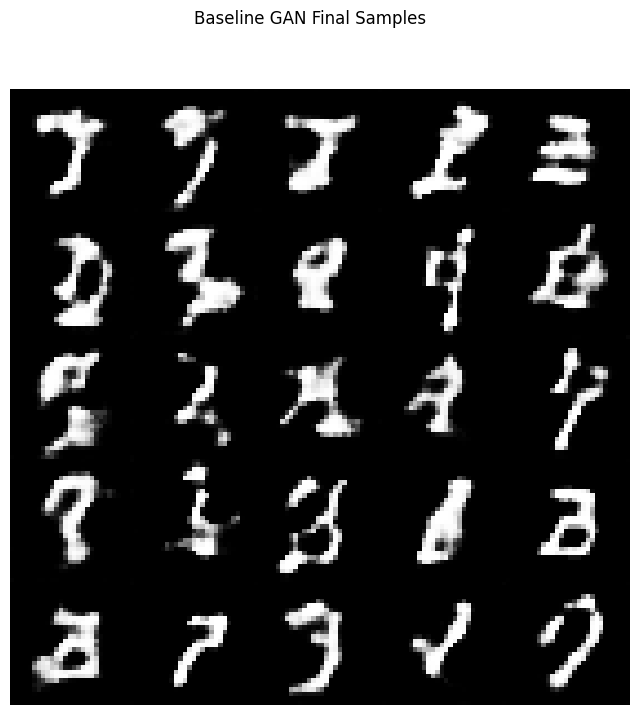

In [18]:
# CELL 14: gan_results_visualization
# Description: Plots baseline GAN losses and generates final samples.

plot_loss_curves(loss_generator_iters, loss_discriminator_iters, title="Baseline GAN Loss Curves")
generate_images(generator, title="Baseline GAN Final Samples")

> ### **Exercise:** Improve the Generator and the Discriminator (you can add some Batch Normalization layers, dropout, etc). Then, generate new samples and compare the results.

In [19]:
# CELL 15: improved_gan_models
# Description: Defines improved Generator and Discriminator with BatchNorm and Dropout.

class ImprovedGenerator(nn.Module):
    def __init__(self):
        super(ImprovedGenerator, self).__init__()
        self.generator = nn.Sequential(
            # Input: (100, 1, 1) -> (128, 7, 7)
            nn.ConvTranspose2d(100, 128, kernel_size=7, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # (128, 7, 7) -> (64, 14, 14)
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # (64, 14, 14) -> (32, 28, 28)
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            # (32, 28, 28) -> (1, 28, 28)
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.generator(x)


class ImprovedDiscriminator(nn.Module):
    def __init__(self):
        super(ImprovedDiscriminator, self).__init__()
        self.discriminator = nn.Sequential(
            # Input: (1, 28, 28) -> (64, 14, 14)
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25),

            # (64, 14, 14) -> (128, 7, 7)
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25),

            # (128, 7, 7) -> (1, 1, 1)
            nn.Conv2d(128, 1, kernel_size=7, stride=1, padding=0),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.discriminator(x)

Improved GAN | Epoch [1/5], Step [1875/1875], Loss D: 1.1425, Loss G: 1.0155


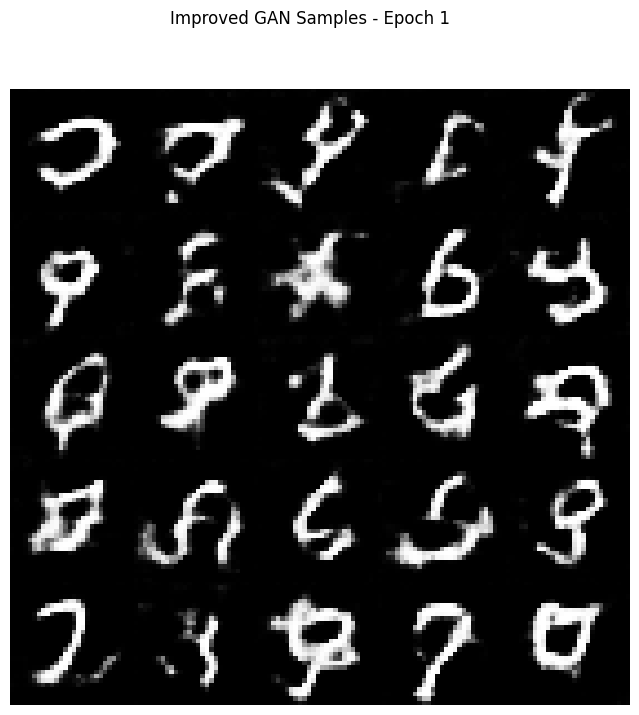

Improved GAN | Epoch [2/5], Step [1875/1875], Loss D: 1.3442, Loss G: 1.1983


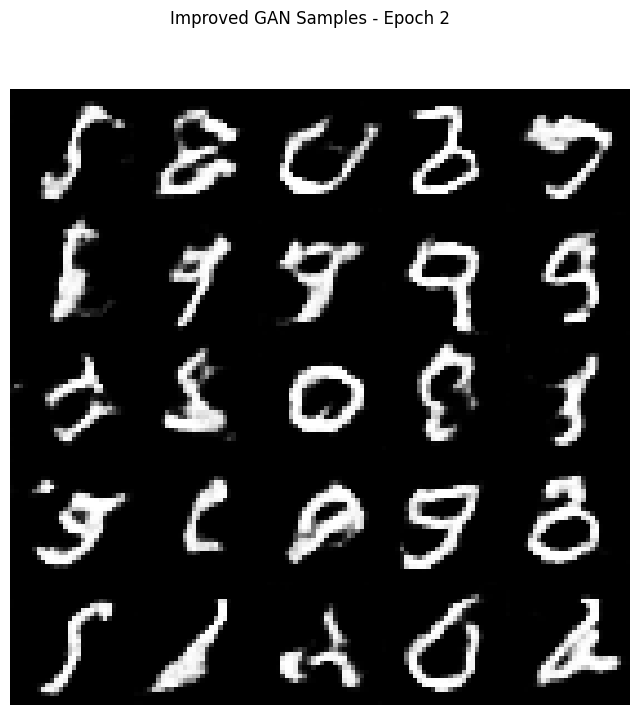

Improved GAN | Epoch [3/5], Step [1875/1875], Loss D: 1.3185, Loss G: 0.8580


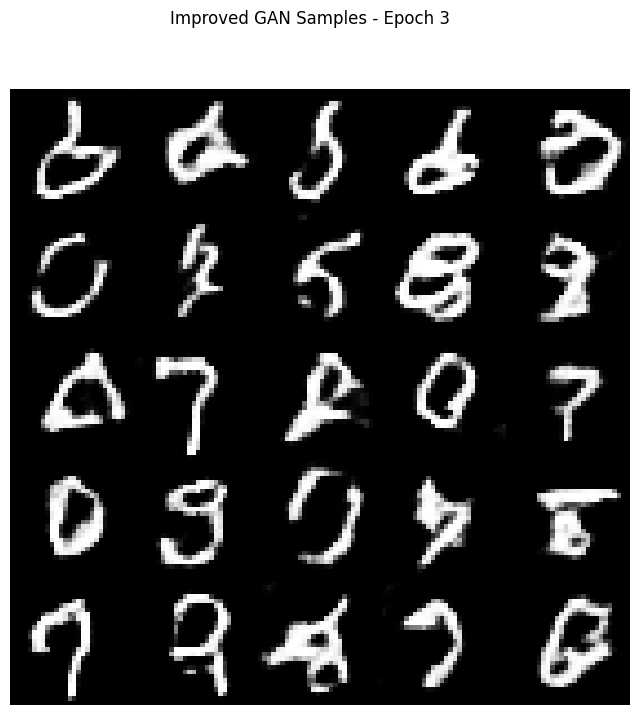

Improved GAN | Epoch [4/5], Step [1875/1875], Loss D: 1.3130, Loss G: 0.9201


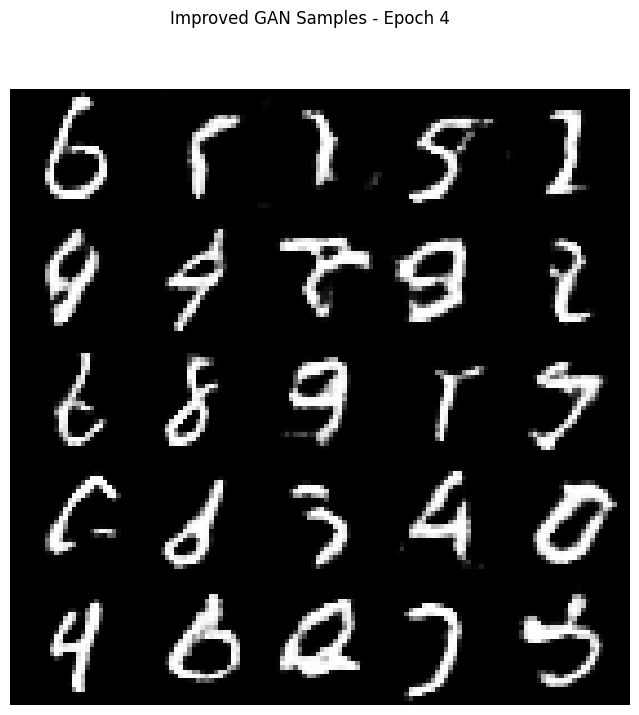

Improved GAN | Epoch [5/5], Step [1875/1875], Loss D: 1.1655, Loss G: 0.8180


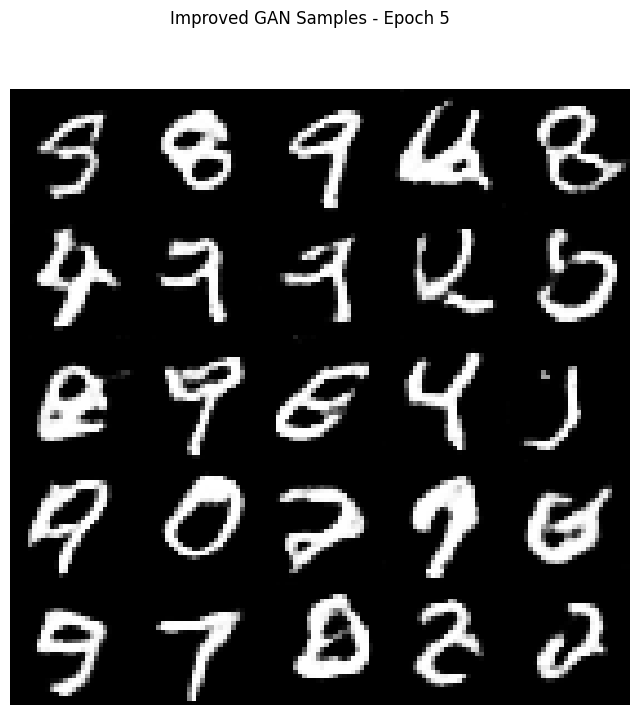

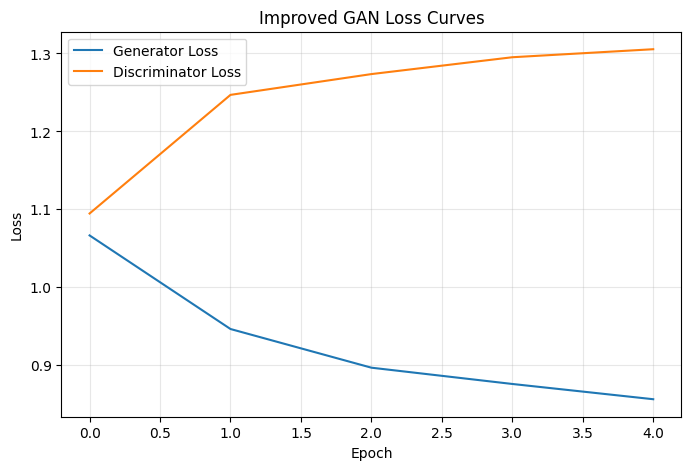

Baseline GAN samples:


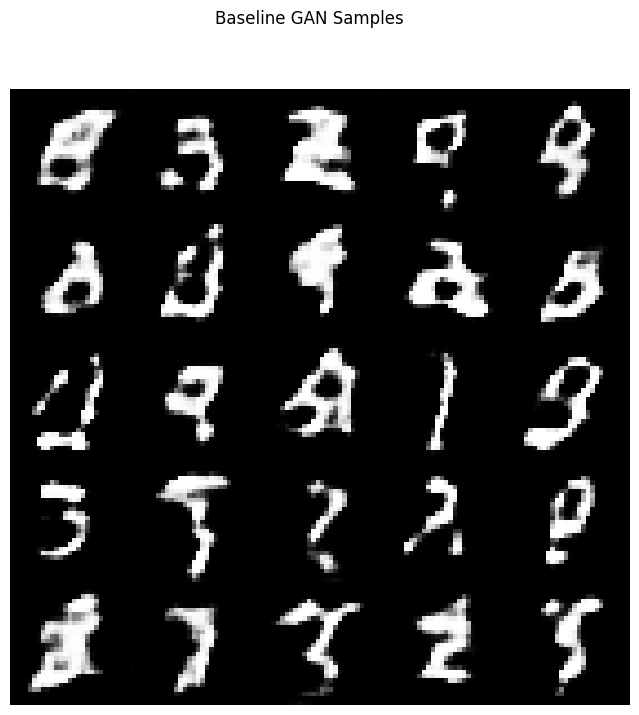

Improved GAN samples:


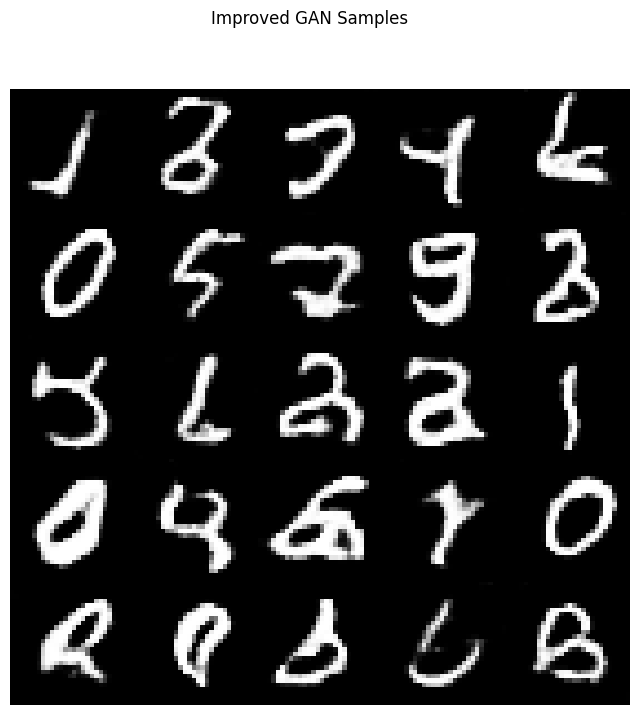

In [20]:
# CELL 16: improved_gan_training_and_comparison
# Description: Trains the improved GAN and compares its samples and loss curves with the baseline GAN.

improved_generator = ImprovedGenerator().to(device)
improved_discriminator = ImprovedDiscriminator().to(device)

improved_generator_optimizer = torch.optim.Adam(improved_generator.parameters(), lr=0.0001, betas=(0.5, 0.999))
improved_discriminator_optimizer = torch.optim.Adam(improved_discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999))

improved_loss_generator_iters = []
improved_loss_discriminator_iters = []

def train_improved_gan(epochs=5):
    real_label, fake_label = 1, 0
    criterion = nn.BCELoss()

    for epoch in range(epochs):
        epoch_g_loss = 0.0
        epoch_d_loss = 0.0

        for i, (real_images, _) in enumerate(trainloader):
            batch_size = real_images.size(0)

            real_images = (real_images * 2.0) - 1.0
            real_images = real_images.to(device)

            real_labels = torch.full((batch_size, 1, 1, 1), real_label, dtype=torch.float, device=device)
            fake_labels = torch.full((batch_size, 1, 1, 1), fake_label, dtype=torch.float, device=device)

            # Train discriminator
            improved_discriminator.zero_grad()

            output_real = improved_discriminator(real_images)
            loss_real = criterion(output_real, real_labels)

            noise = generate_noise(batch_size, 100)
            fake_images = improved_generator(noise)
            output_fake = improved_discriminator(fake_images.detach())
            loss_fake = criterion(output_fake, fake_labels)

            loss_d = loss_real + loss_fake
            loss_d.backward()
            improved_discriminator_optimizer.step()

            # Train generator
            improved_generator.zero_grad()
            output_fake_for_g = improved_discriminator(fake_images)
            loss_g = criterion(output_fake_for_g, real_labels)
            loss_g.backward()
            improved_generator_optimizer.step()

            epoch_g_loss += loss_g.item()
            epoch_d_loss += loss_d.item()

            print(
                f'\rImproved GAN | Epoch [{epoch + 1}/{epochs}], Step [{i + 1}/{len(trainloader)}], '
                f'Loss D: {loss_d.item():.4f}, Loss G: {loss_g.item():.4f}',
                end=''
            )

        improved_loss_generator_iters.append(epoch_g_loss / len(trainloader))
        improved_loss_discriminator_iters.append(epoch_d_loss / len(trainloader))
        print()

        generate_images(improved_generator, title=f"Improved GAN Samples - Epoch {epoch + 1}")

train_improved_gan(epochs=5)

plot_loss_curves(improved_loss_generator_iters, improved_loss_discriminator_iters, title="Improved GAN Loss Curves")

print("Baseline GAN samples:")
generate_images(generator, title="Baseline GAN Samples")

print("Improved GAN samples:")
generate_images(improved_generator, title="Improved GAN Samples")

# Diffusion Networks

Reference: [Colab](https://colab.research.google.com/github/st-howard/blog-notebooks/blob/main/MNIST-Diffusion/Diffusion%20Digits%20-%20Generating%20MNIST%20Digits%20from%20noise%20with%20HuggingFace%20Diffusers.ipynb#scrollTo=a1a0807f)

In [25]:
# CELL 17: install_diffusers_modern_stack_with_transformers
# Description: Installs a clean modern Diffusers stack including transformers.

%%capture
!pip uninstall -y diffusers transformers huggingface_hub accelerate datasets tokenizers safetensors
!pip install --no-cache-dir --upgrade "diffusers[torch]" transformers accelerate datasets safetensors

In [22]:
# CELL 18: diffusion_imports_config_and_dataset
# Description: Imports diffusion libraries, defines the configuration, and prepares the MNIST dataset for diffusion training.

# Pytorch
import torch
import torchvision

# HuggingFace
import datasets
import diffusers
import accelerate

# Training and Visualization
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import os
import PIL
from torch.utils.data import DataLoader, Subset

In [23]:
# CELL 18.2

from dataclasses import dataclass

@dataclass
class TrainingConfig:
    image_size = 32
    train_batch_size = 32
    eval_batch_size = 32
    num_epochs = 5
    gradient_accumulation_steps = 1
    learning_rate = 1e-4
    lr_warmpup_steps = 500
    mixed_precision = 'fp16' if torch.cuda.is_available() else 'no'
    seed = 0

config = TrainingConfig()

mnist_dataset = datasets.load_dataset('mnist', split='train')

def transform(dataset):
    preprocess = torchvision.transforms.Compose(
        [
            torchvision.transforms.Resize((config.image_size, config.image_size)),
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Lambda(lambda x: 2 * (x - 0.5)),
        ]
    )
    images = [preprocess(image) for image in dataset["image"]]
    return {"images": images}

mnist_dataset.reset_format()
mnist_dataset.set_transform(transform)

mnist_dataset = Subset(mnist_dataset, range(20000))

train_dataloader = torch.utils.data.DataLoader(
    mnist_dataset,
    batch_size=config.train_batch_size,
    shuffle=True,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

mnist/train-00000-of-00001.parquet:   0%|          | 0.00/15.6M [00:00<?, ?B/s]

mnist/test-00000-of-00001.parquet:   0%|          | 0.00/2.60M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [26]:
# CELL 19: diffusion_model_scheduler_optimizer
# Description: Creates the diffusion UNet, scheduler, optimizer, and learning-rate scheduler.

model = diffusers.UNet2DModel(
    sample_size=config.image_size,
    in_channels=1,
    out_channels=1,
    layers_per_block=2,
    block_out_channels=(128, 128, 256, 512),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
)



Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [28]:
noise_scheduler = diffusers.DDPMScheduler(num_train_timesteps=200)

In [29]:
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)

In [30]:
# Cosine learning rate scheduler

lr_scheduler = diffusers.optimization.get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=config.lr_warmpup_steps,
    num_training_steps=(len(train_dataloader) * config.num_epochs),
)

In [31]:
# CELL 20: diffusion_training_loop
# Description: Trains the diffusion model.

def train_loop(
        config,
        model,
        noise_scheduler,
        optimizer,
        train_dataloader,
        lr_scheduler):

    accelerator = accelerate.Accelerator(
        mixed_precision=config.mixed_precision,
        gradient_accumulation_steps=config.gradient_accumulation_steps,
    )

    model, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(
        model, optimizer, train_dataloader, lr_scheduler
    )

    for epoch in range(config.num_epochs):
        progress_bar = tqdm(total=len(train_dataloader),
                            disable=not accelerator.is_local_main_process)
        progress_bar.set_description(f"Epoch {epoch}")

        for step, batch in enumerate(train_dataloader):
            clean_images = batch['images']
            noise = torch.randn_like(clean_images)
            batch_size = clean_images.shape[0]

            timesteps = torch.randint(
                0,
                noise_scheduler.num_train_timesteps,
                (batch_size,),
                device=clean_images.device
            ).long()

            noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

            with accelerator.accumulate(model):
                noise_pred = model(noisy_images, timesteps)["sample"]
                loss = torch.nn.functional.mse_loss(noise_pred, noise)
                accelerator.backward(loss)

                accelerator.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()

            progress_bar.update(1)
            logs = {
                "loss": loss.detach().item(),
                "lr": lr_scheduler.get_last_lr()[0],
            }
            progress_bar.set_postfix(**logs)

    accelerator.unwrap_model(model)

In [32]:
args = (config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler)
accelerate.notebook_launcher(train_loop, args, num_processes=1)

Launching training on one GPU.


  0%|          | 0/625 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:173: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]

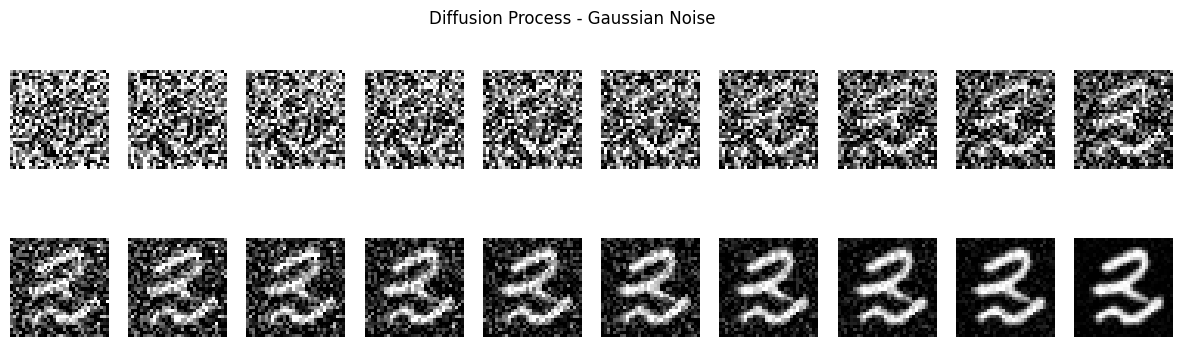

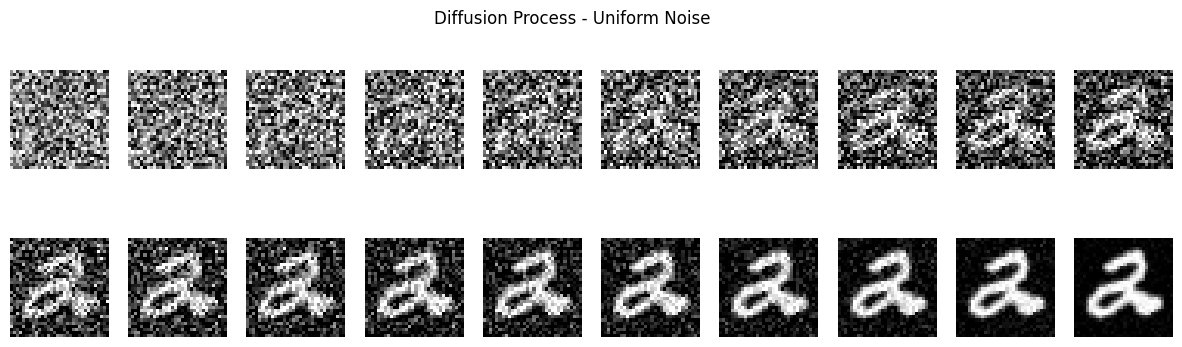

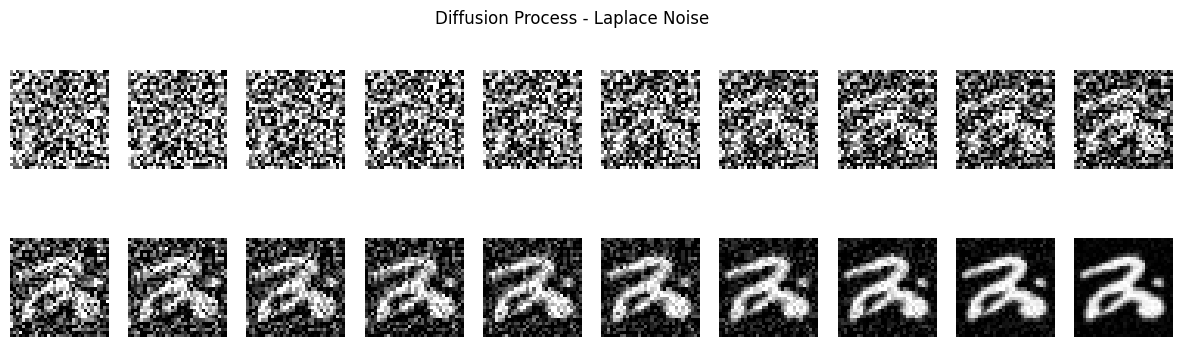

In [33]:
# CELL 21: diffusion_sampling_with_different_noise
# Description: Generates diffusion samples using different initial noise distributions.

@torch.no_grad()
def sample(unet, scheduler, seed, noise_type="gaussian", num_inference_steps=200, save_process_dir=None):
    torch.manual_seed(seed)

    if save_process_dir and not os.path.exists(save_process_dir):
        os.mkdir(save_process_dir)

    scheduler.set_timesteps(num_inference_steps)

    unet_device = next(unet.parameters()).device

    if noise_type == "gaussian":
        image = torch.randn((1, 1, 32, 32), device=unet_device)
    elif noise_type == "uniform":
        image = (2 * torch.rand((1, 1, 32, 32), device=unet_device)) - 1
    elif noise_type == "laplace":
        laplace = torch.distributions.Laplace(
            torch.tensor(0.0, device=unet_device),
            torch.tensor(1.0, device=unet_device)
        )
        image = laplace.sample((1, 1, 32, 32))
    else:
        raise ValueError("noise_type must be one of: 'gaussian', 'uniform', 'laplace'")

    images = []
    store_every = max(1, num_inference_steps // 20)

    for step_index, t in enumerate(scheduler.timesteps):
        model_output = unet(image, t)["sample"]
        image = scheduler.step(model_output, t, image).prev_sample

        if step_index % store_every == 0:
            save_image = torchvision.transforms.ToPILImage()(((image.squeeze(0).clamp(-1, 1) + 1) / 2).cpu())
            images.append(save_image)

    final_image = torchvision.transforms.ToPILImage()(((image.squeeze(0).clamp(-1, 1) + 1) / 2).cpu())
    return final_image, images


def plot_diffusion_process(images, title):
    cols = min(10, len(images))
    rows = int(np.ceil(len(images) / cols))
    fig, axs = plt.subplots(rows, cols, figsize=(15, 2 * rows))

    if rows == 1:
        axs = np.array(axs).reshape(1, -1)

    for ax in axs.flat:
        ax.axis('off')

    for idx, img in enumerate(images):
        r = idx // cols
        c = idx % cols
        axs[r, c].imshow(img, cmap='gray')
        axs[r, c].axis('off')

    plt.suptitle(title)
    plt.show()


test_image_gaussian, images_gaussian = sample(model, noise_scheduler, seed=2, noise_type="gaussian")
test_image_uniform, images_uniform = sample(model, noise_scheduler, seed=2, noise_type="uniform")
test_image_laplace, images_laplace = sample(model, noise_scheduler, seed=2, noise_type="laplace")

plot_diffusion_process(images_gaussian, "Diffusion Process - Gaussian Noise")
plot_diffusion_process(images_uniform, "Diffusion Process - Uniform Noise")
plot_diffusion_process(images_laplace, "Diffusion Process - Laplace Noise")

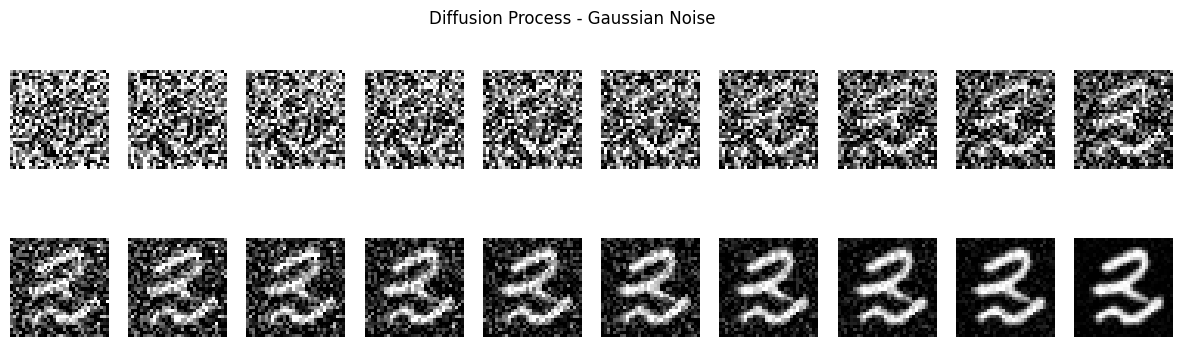

In [35]:
test_image, images = sample(model, noise_scheduler, 2)
plot_diffusion_process(images, "Diffusion Process - Gaussian Noise")

> ### **Exercise:** Compare the results with the GAN model. Change the noise used in the Diffusion Networks and generate new samples.

[Schedulers](https://huggingface.co/docs/diffusers/v0.3.0/en/api/schedulers#diffusers.DDPMScheduler)

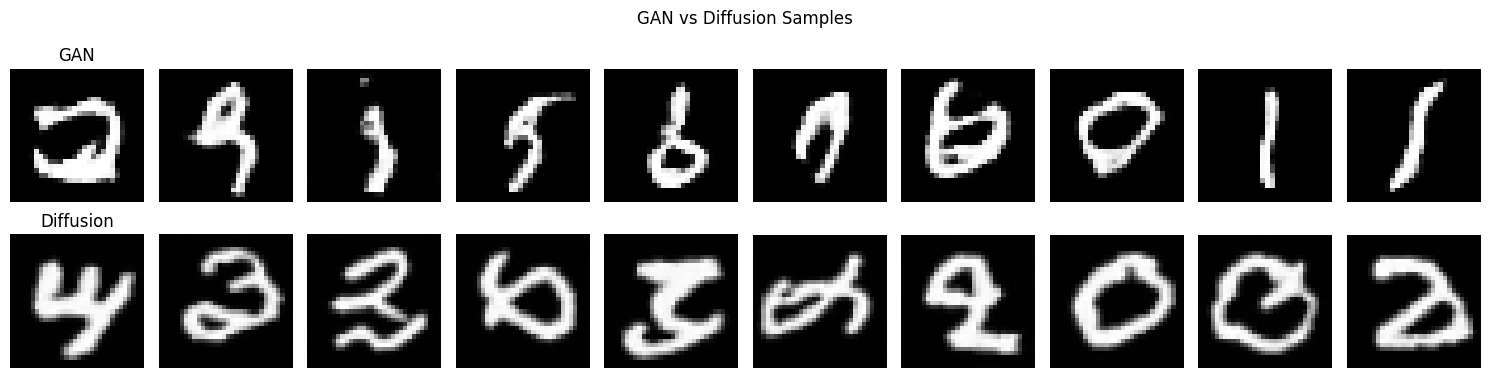

In [36]:
# CELL 22: gan_vs_diffusion_comparison
# Description: Compares GAN samples with diffusion samples.

# Generate GAN samples
improved_generator.eval()
with torch.no_grad():
    gan_noise = torch.randn(10, 100, 1, 1).to(device)
    gan_samples = improved_generator(gan_noise)
    gan_samples = ((gan_samples + 1.0) / 2.0).cpu().numpy()

# Generate Diffusion samples
diffusion_samples = []
for seed in range(10):
    img, _ = sample(model, noise_scheduler, seed=seed, noise_type="gaussian", num_inference_steps=200)
    diffusion_samples.append(np.array(img))

# Plot comparison
fig, axs = plt.subplots(2, 10, figsize=(15, 4))

for i in range(10):
    axs[0, i].imshow(gan_samples[i].squeeze(), cmap='gray')
    axs[0, i].axis('off')
    axs[0, i].set_title("GAN" if i == 0 else "")

    axs[1, i].imshow(diffusion_samples[i], cmap='gray')
    axs[1, i].axis('off')
    axs[1, i].set_title("Diffusion" if i == 0 else "")

plt.suptitle("GAN vs Diffusion Samples")
plt.tight_layout()
plt.show()

In [ ]:
import time

while True:
    time.sleep(100000)